# Combined Chromatin Deconvolution Run
March 7, 2024

Trial combined chromatin deconvolution model run

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [41]:
from src.config import load_yl_rg1_vst_config
from cc_src.combined_chromatin_model import CombinedChromatinModel

config1 = load_yl_rg1_vst_config(1)
config2 = load_yl_rg1_vst_config(2)
combined_model = CombinedChromatinModel(config1, config2)


In [55]:
gene_name = "SSK22"
combined_model.load_combined_mnase_gene(gene_name)

Loading MNase reads for YCR073C/SSK22...Loading chromosome reads: 3
Done.
Loading MNase reads for YCR073C/SSK22...Loading chromosome reads: 3
Done.


In [64]:
# Deconvolve
combined_model.deconvolve(verbose=True)

Deconvolving combined model with gamma=0.006, gamma_prime=0
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Mar 07 04:30:00 PM: Your problem has 45400 variables, 1 constraints, and 1 parameters.
(CVXPY) Mar 07 04:30:00 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 07 04:30:00 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 07 04:30:00 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 07 04:30:00 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Mar 07 04:30:00 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr 

(CVXPY) Mar 07 04:30:15 PM: 25  1.5e-04  2.9e-04  8.4e-06  3.79e-01   2.152412729e+03   2.152412717e+03   1.5e-04  6.77  
(CVXPY) Mar 07 04:30:15 PM: 26  8.8e-05  1.8e-04  4.7e-06  3.46e-01   2.132753947e+03   2.132753832e+03   8.8e-05  6.89  
(CVXPY) Mar 07 04:30:15 PM: 27  6.2e-05  1.2e-04  3.2e-06  3.61e-01   2.119992566e+03   2.119992411e+03   6.2e-05  7.02  
(CVXPY) Mar 07 04:30:15 PM: Optimizer terminated. Time: 7.15    
(CVXPY) Mar 07 04:30:15 PM: 
(CVXPY) Mar 07 04:30:15 PM: 
(CVXPY) Mar 07 04:30:15 PM: Interior-point solution summary
(CVXPY) Mar 07 04:30:15 PM:   Problem status  : PRIMAL_AND_DUAL_FEASIBLE
(CVXPY) Mar 07 04:30:15 PM:   Solution status : OPTIMAL
(CVXPY) Mar 07 04:30:15 PM:   Primal.  obj: 2.1199925662e+03    nrm: 1e+04    Viol.  con: 1e-06    var: 1e+02    cones: 0e+00  
(CVXPY) Mar 07 04:30:15 PM:   Dual.    obj: 2.1199924115e+03    nrm: 2e+03    Viol.  con: 0e+00    var: 3e-13    cones: 0e+00  
------------------------------------------------------------------

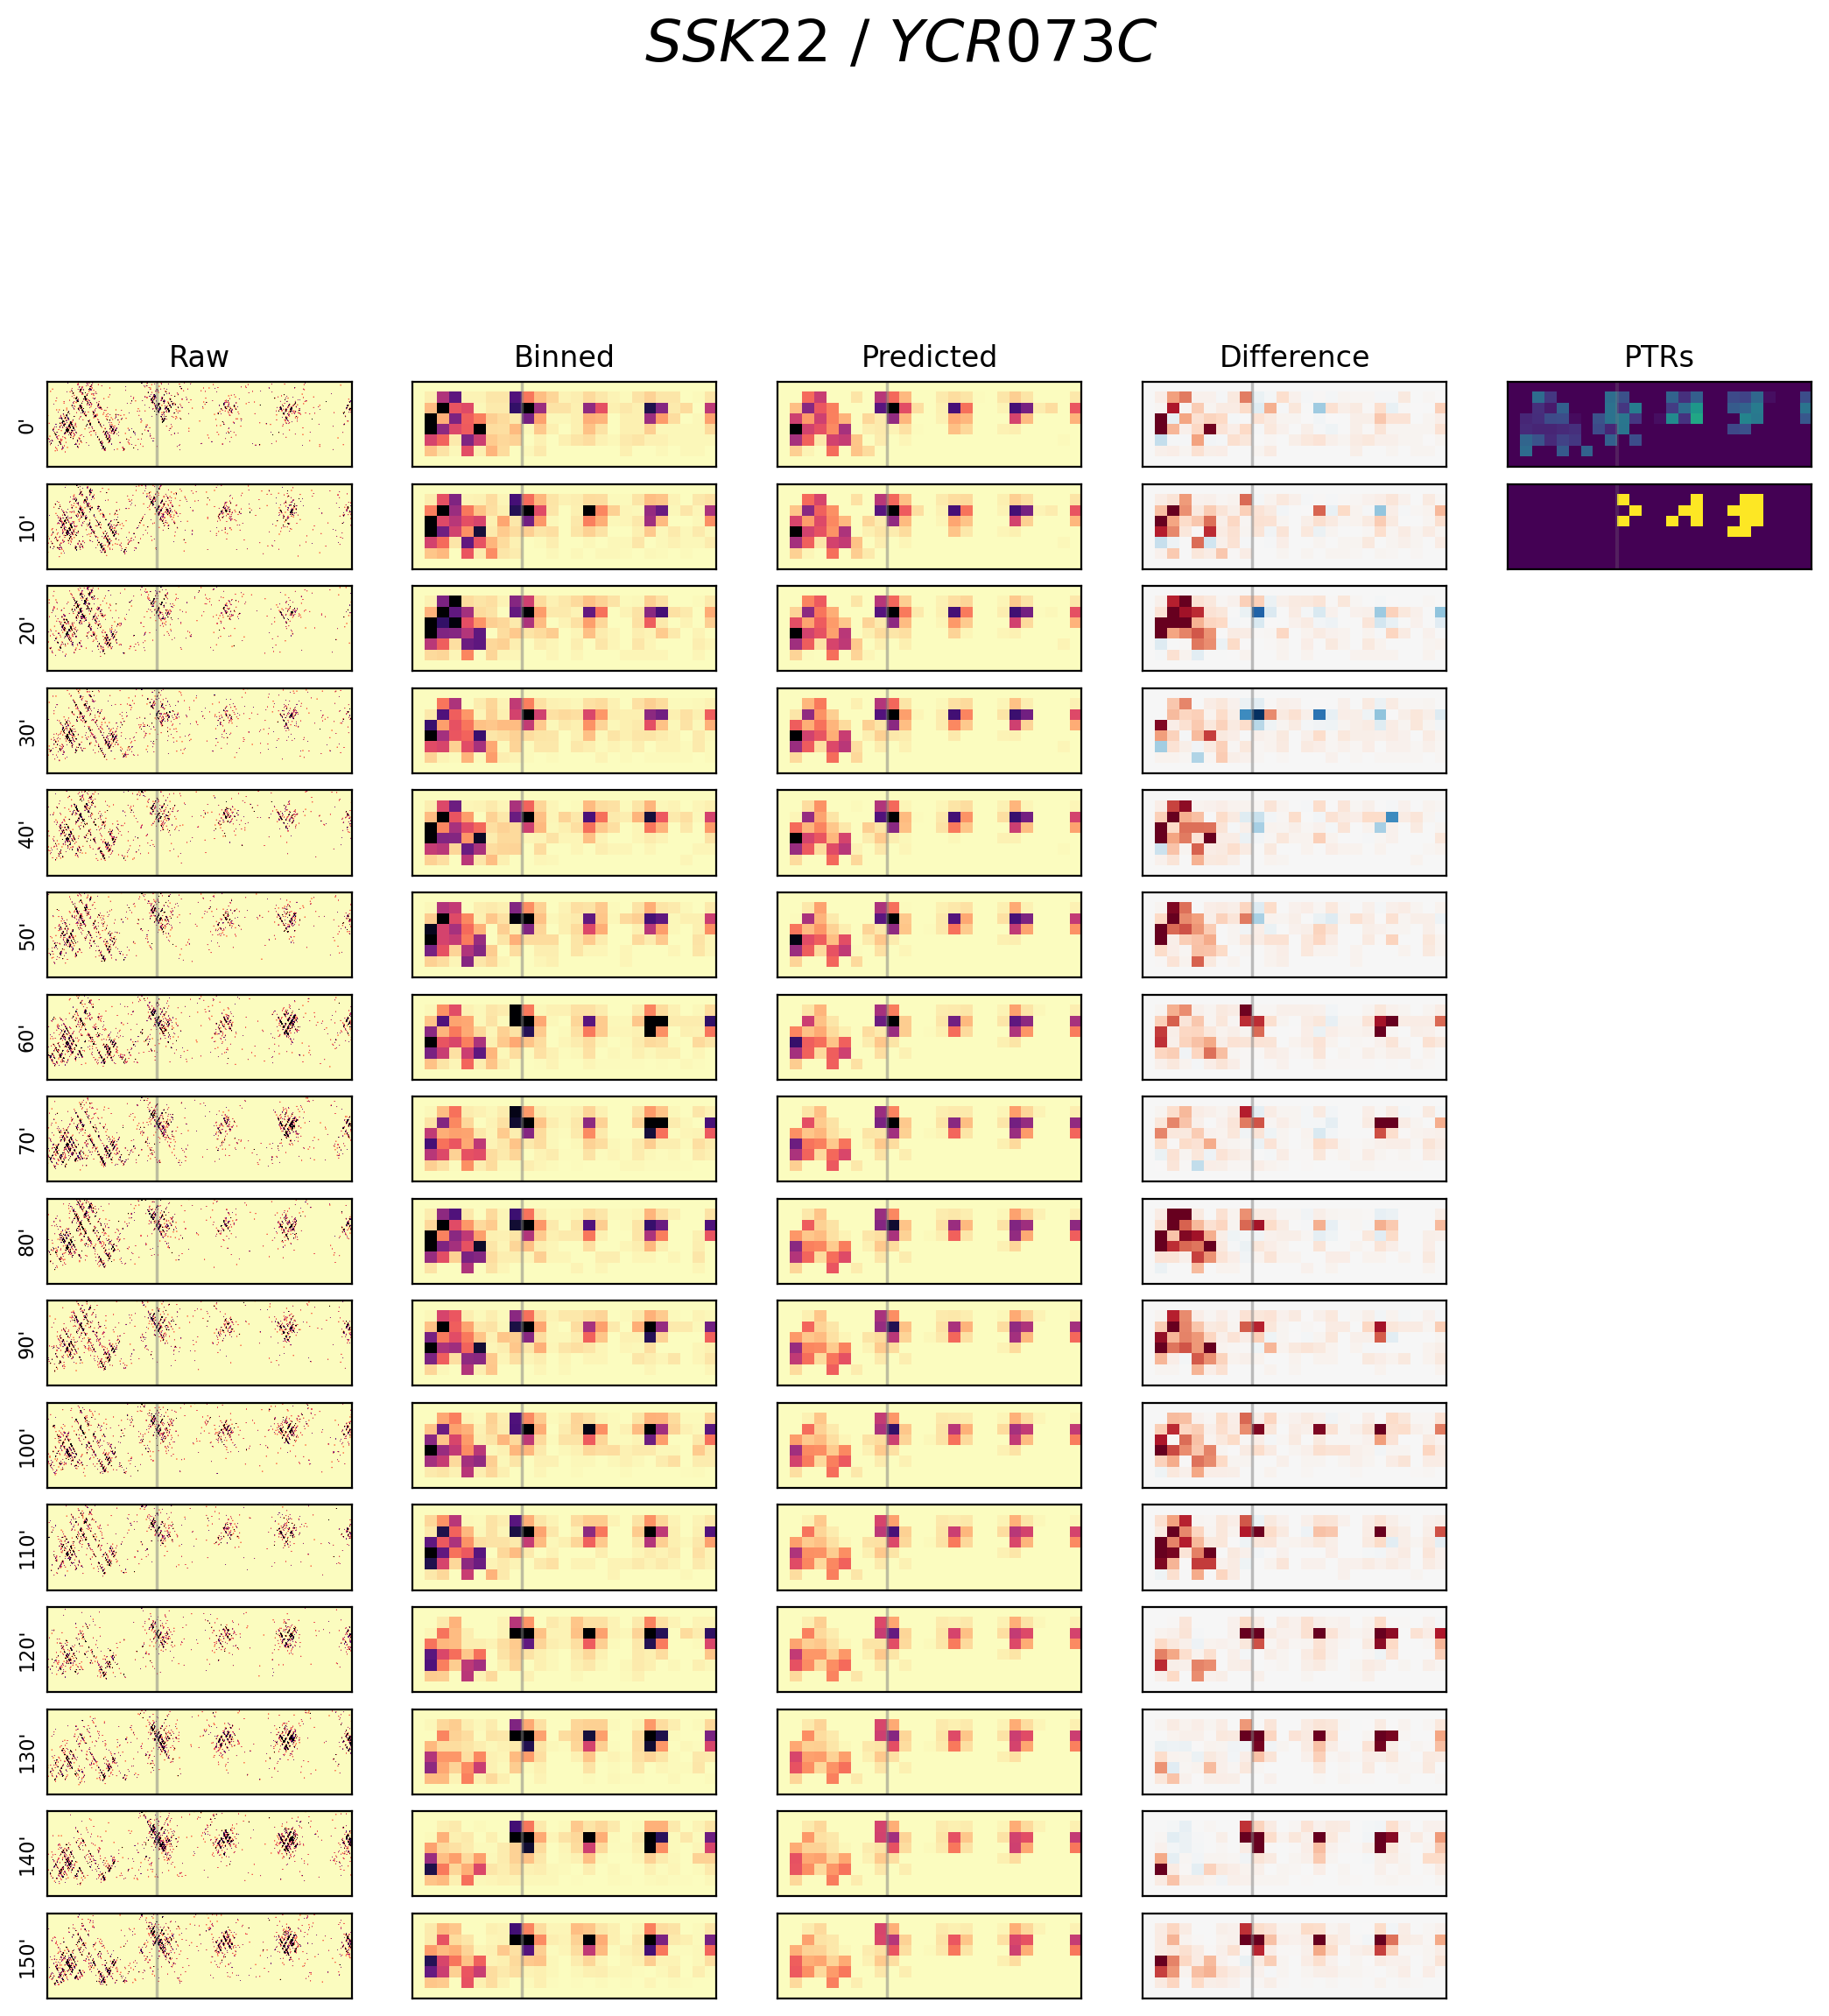

In [65]:
fig = combined_model.plot_raw_prediction(1, vmax=50)

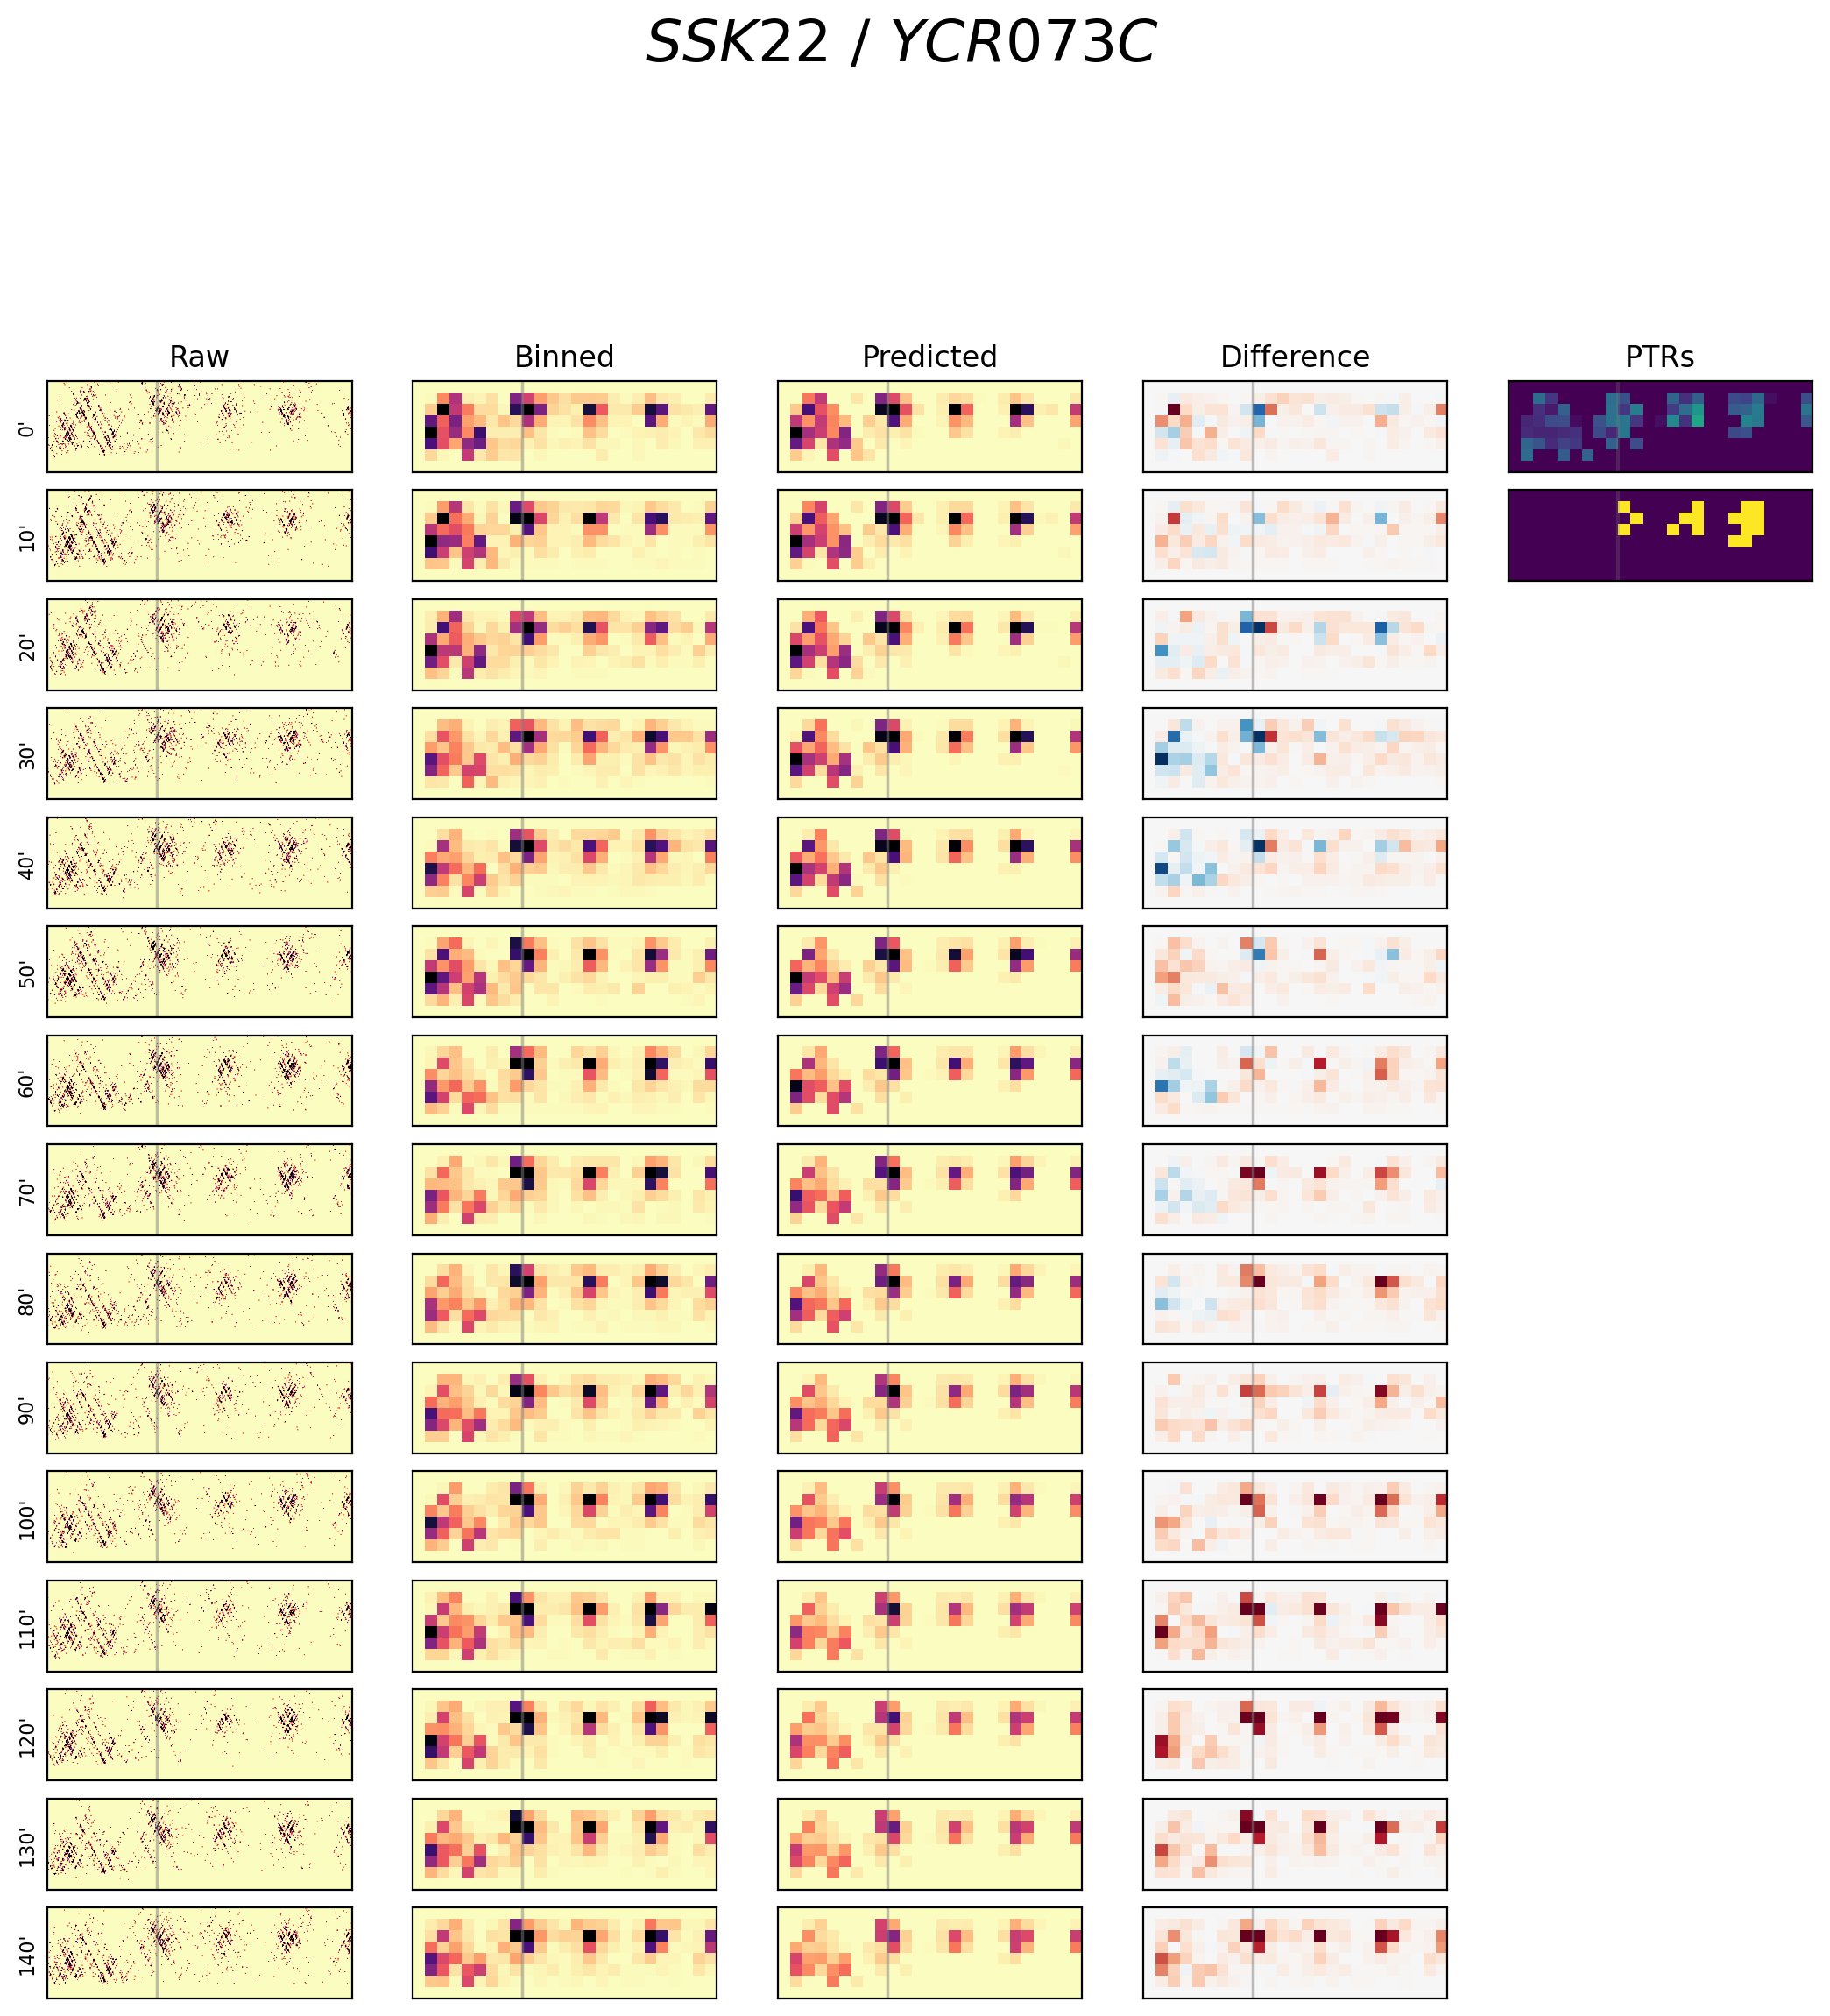

In [66]:
fig = combined_model.plot_raw_prediction(2, vmax=50)

In [67]:
# Deconvolve the combined gene expression model
from src.config import load_combined_yl_alpha_vst_gene_expression_config
from src.model import Model

combined_ge_config = load_combined_yl_alpha_vst_gene_expression_config()
ge_model = Model(combined_ge_config, gene_name)
ge_model.deconvolve_find_optimal_gamma()

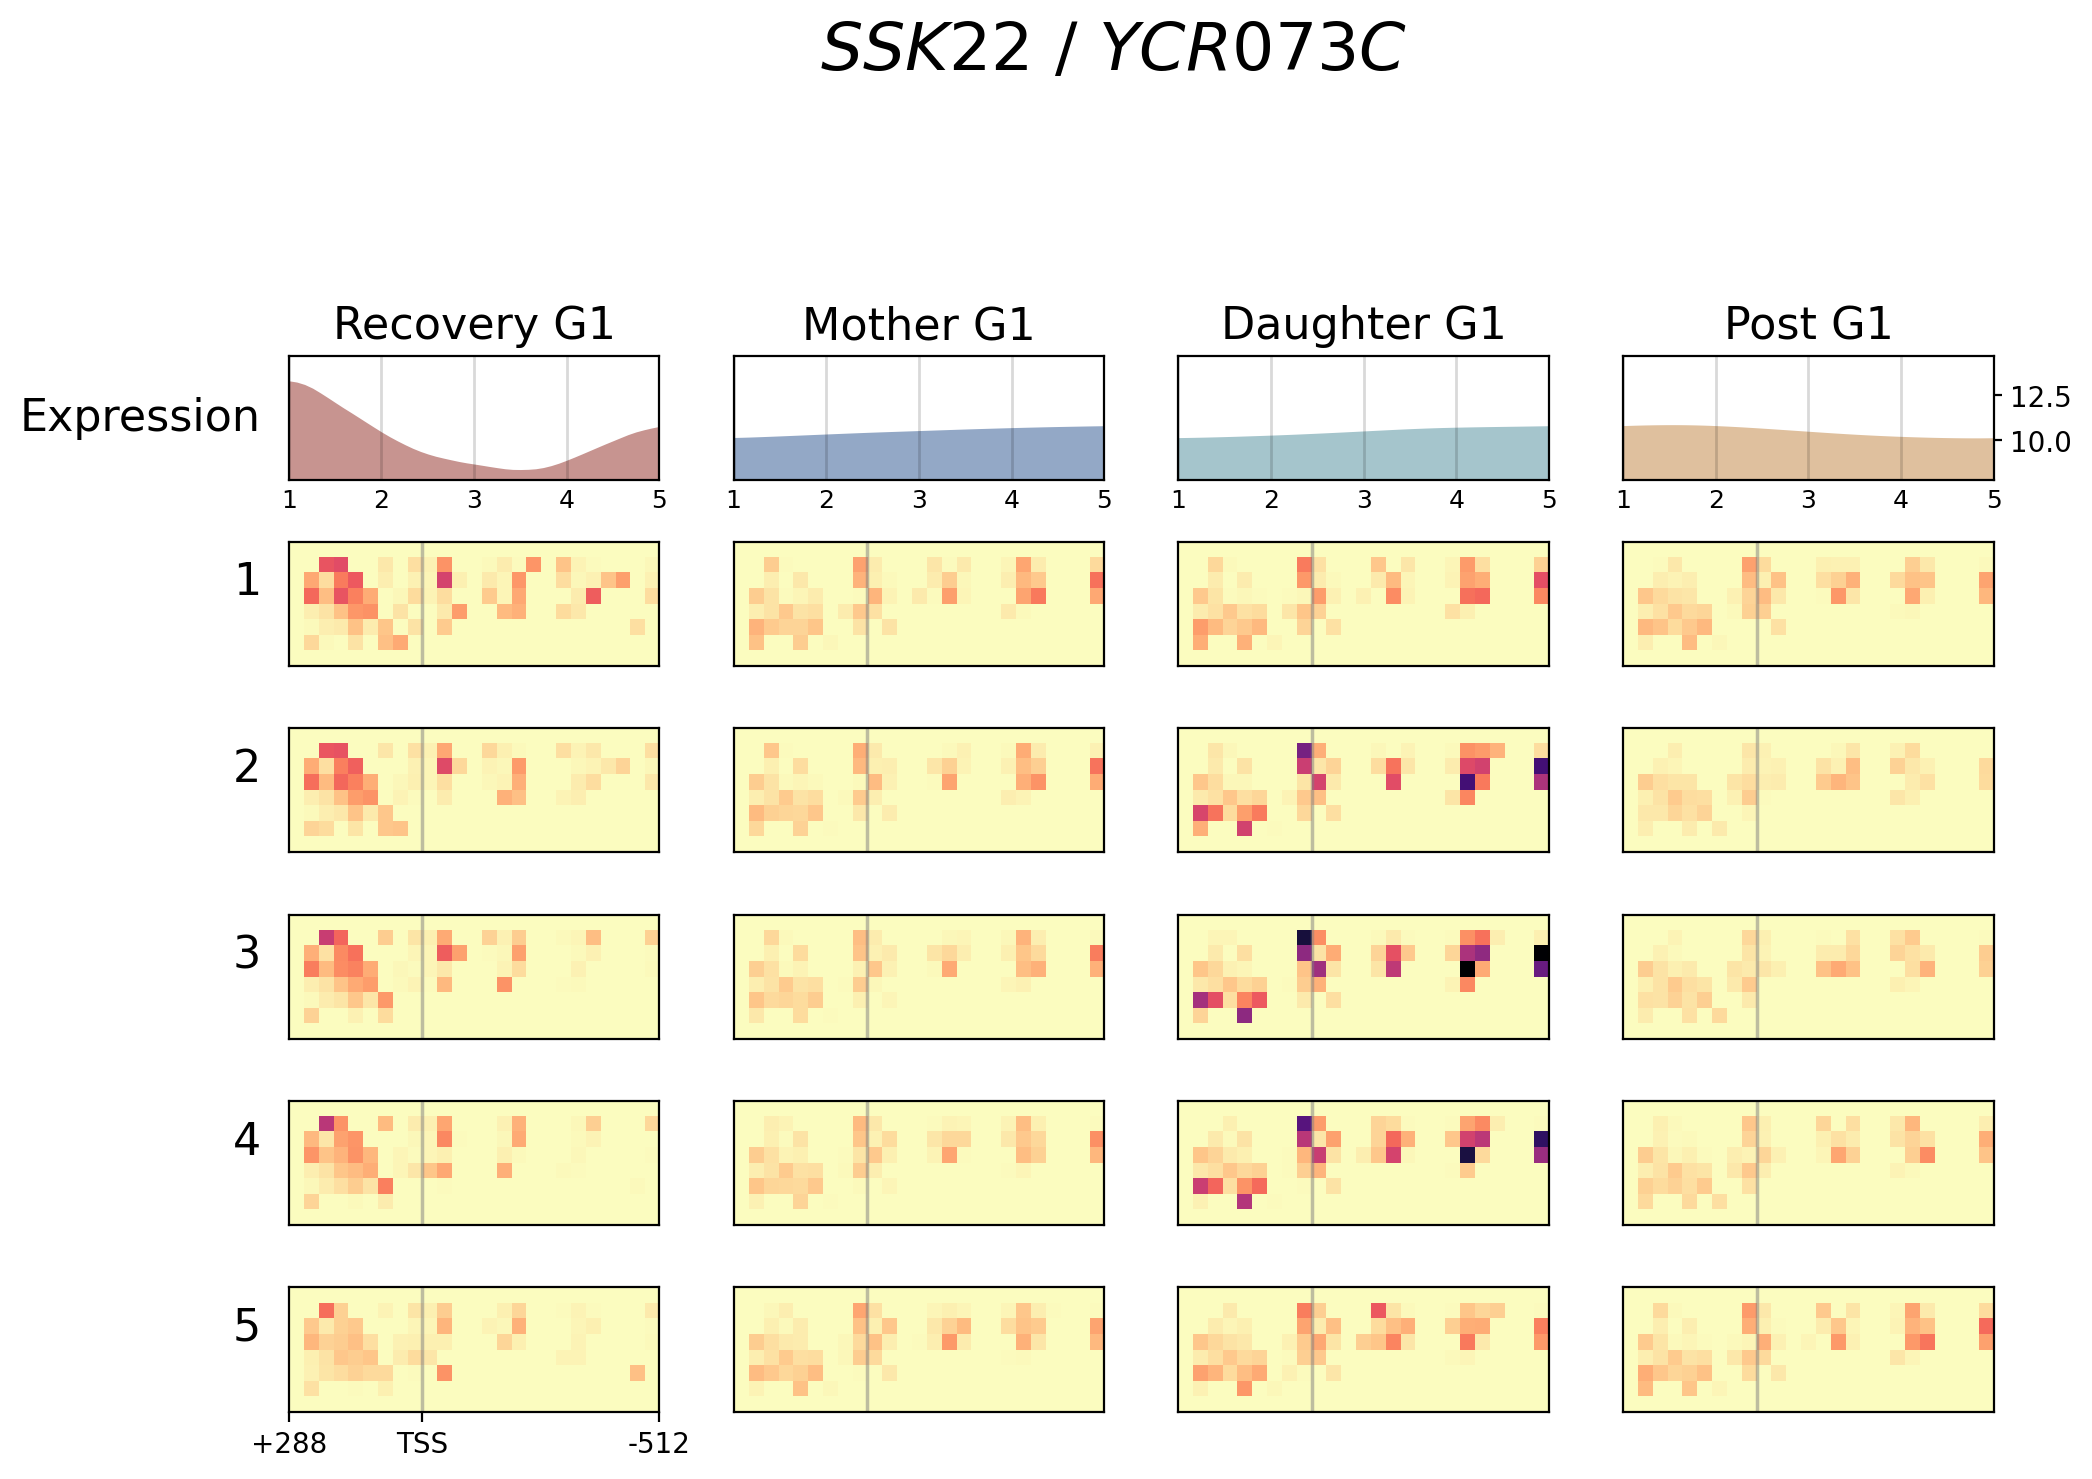

In [68]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=50, ge_model=ge_model)